# Ewaluacja architektur rozpoznawania obrazu (OCR) w zadaniu odczytu odręcznego pisma ciągłego

## 1. Wstęp i założenia badawcze
Celem niniejszego eksperymentu jest analiza porównawcza skuteczności różnych architektur systemów Optical Character Recognition (OCR) w zadaniu transkrypcji zlewającego się pisma odręcznego (tzw. kursywy). 

W celu izolacji błędu i uniknięcia problemu kaskadowej propagacji błędów z modułu detekcji (Text Detection), badania przeprowadzono na pre-segmentowanych liniach tekstu ze zbioru **IAM Handwriting Database**. Oznacza to, że ocenie podlega wyłącznie moduł rozpoznawania znaków (Text Recognition).

### 1.1 Metryki ewaluacyjne
Skuteczność modeli oceniana jest za pomocą trzech rygorystycznych metryk:
* **Odległość Levenshteina (Levenshtein Distance):** Bezwzględna miara błędu na poziomie znaków. Określa minimalną liczbę jednoznakowych operacji edycyjnych (wstawienie, usunięcie lub zamiana znaku) niezbędnych do przekształcenia wygenerowanego tekstu w tekst referencyjny (Ground Truth). W naszym badaniu obrazuje to średnią, fizyczną liczbę pomyłek na jedną linijkę tekstu.
* **CER (Character Error Rate):** Znormalizowany odsetek błędnie rozpoznanych znaków. Obliczany jako stosunek odległości Levenshteina (sumy podstawień $S$, usunięć $D$ i wstawień $I$) do całkowitej liczby znaków w tekście referencyjnym ($N$): 
  $CER = \frac{S + D + I}{N}$
* **WER (Word Error Rate):** Odsetek błędnie rozpoznanych całych słów. Weryfikuje zdolność modelu do zachowania poprawności semantycznej na poziomie leksykalnym (czy model generuje sensowne słowa, czy tylko losowe zlepki liter).

In [1]:
import sys
print("Używam Pythona z tej ścieżki:")
print(sys.executable)

Używam Pythona z tej ścieżki:
C:\Users\aleks\OneDrive\Pulpit\Documents\IndividualPeoject\.venv\Scripts\python.EXE


In [1]:
import pytesseract
import jiwer
from datasets import load_dataset
import Levenshtein
import matplotlib.pyplot as plt
import numpy as np
import cv2
from paddleocr import PaddleOCR
import gc
import logging
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import easyocr

C:\Users\aleks\OneDrive\Pulpit\Documents\IndividualPeoject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\aleks\OneDrive\Pulpit\Documents\IndividualPeoject\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


### 1.2. Inicjalizacja środowiska testowego oraz przygotowanie zbioru danych
W tej sekcji następuje załadowanie ustandaryzowanego zbioru testowego do pamięci operacyjnej (RAM) oraz przygotowanie pierwszego silnika rozpoznającego – Tesseract OCR. 

Z punktu widzenia metodologii badań, kluczowe jest zapewnienie pełnej powtarzalności (reprodukowalności) eksperymentu. Z tego względu wprost deklarujemy ścieżkę do pliku wykonywalnego silnika Tesseract zainstalowanego w systemie operacyjnym badacza. Każdy z ewaluowanych w tym dokumencie modeli zostanie przetestowany na dokładnie tym samym, deterministycznym podzbiorze danych (np. pierwszych 200 próbkach ze zbioru testowego), co gwarantuje rzetelność i porównywalność ostatecznych metryk WER i CER.

In [2]:
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

dataset = load_dataset("Teklia/IAM-line")
test_data = dataset['test']
final_metrics = {}

### 1.3. Wizualna inspekcja i charakterystyka zbioru danych (Exploratory Data Analysis)
Przed przystąpieniem do właściwych testów wydajnościowych, konieczne jest przeprowadzenie wstępnej, wizualnej analizy próbki badawczej. Poniższy skrypt pobiera i wyświetla losowe segmenty (linie tekstu) ze zbioru IAM Handwriting Database. 

Celem tej operacji jest naoczna weryfikacja stopnia skomplikowania problemu badawczego. Pozwala to zaobserwować kluczowe trudności związane z przetwarzaniem odręcznego pisma ciągłego, takie jak:
* Występowanie silnych ligatur (fizyczne łączenie znaków, utrudniające segmentację),
* Zmienność grubości linii, pochylenia (slant) i rozmiaru liter w zależności od stylu piszącego (inter-writer variability),
* Naturalne zniekształcenia i szum tła.

Zrozumienie tych właściwości pozwala lepiej zinterpretować późniejsze błędy klasycznych algorytmów OCR.

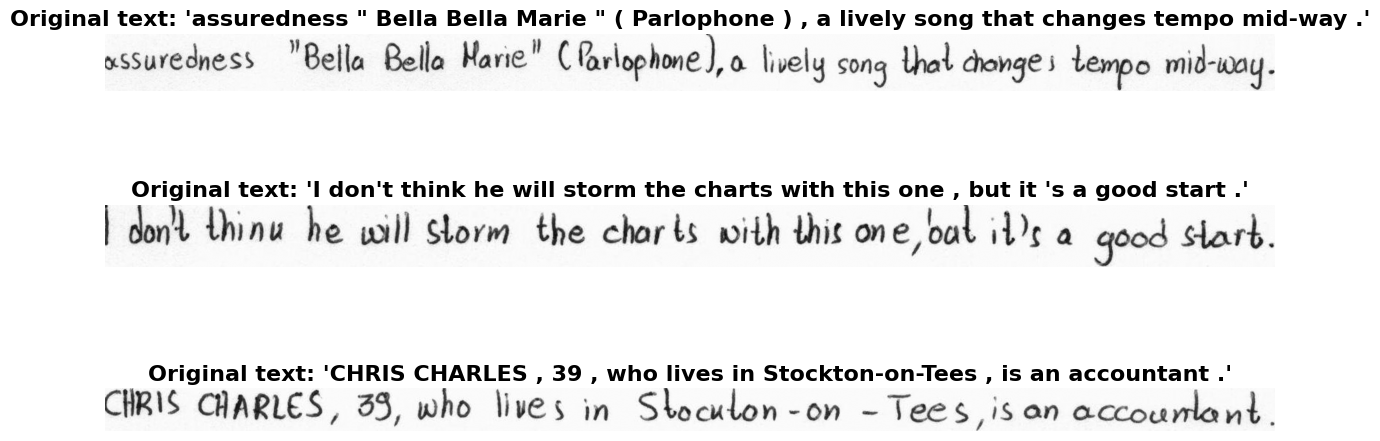

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))

for i in range(3):

    obrazek = test_data[i]['image']
    real = test_data[i]['text']

    axes[i].imshow(obrazek, cmap='gray')

    axes[i].set_title(f"Original text: '{real}'", fontsize=16, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
    

### 1.4. Optymalizacja rozmiaru próby badawczej (Sampling)
Pełny zbiór testowy IAM Handwriting Database zawiera tysiące unikalnych segmentów tekstu. Przeprowadzenie pełnej ewaluacji na całym zbiorze, szczególnie w przypadku ewaluacji ciężkich, głębokich modeli opartych na architekturze Transformer (jak TrOCR), generowałoby nieuzasadnione obciążenie zasobów sprzętowych oraz drastycznie wydłużało czas pojedynczej iteracji eksperymentu.

Z inżynieryjnego punktu widzenia zdecydowano się na ograniczenie puli testowej do reprezentatywnej podpróby liczącej 200 losowych linii tekstu (`TEST_LIMIT = 200`). Ze względu na gigantyczne, spodziewane dysproporcje w skuteczności poszczególnych architektur (rzędu kilkudziesięciu punktów procentowych w metryce CER), taka wielkość próby jest w zupełności wystarczająca do wykazania wyraźnych i powtarzalnych różnic skuteczności, zachowując jednocześnie akceptowalny czas obliczeń.

In [4]:
print(len(test_data))
TEST_LIMIT = 200

2915


## 2. Badanie punktu odniesienia (Baseline): Tesseract OCR
Tesseract reprezentuje klasyczne podejście do problemu analizy obrazu dokumentów. Chociaż w nowszych wersjach (v4+) wykorzystuje on sieci rekurencyjne (LSTM), jego architektura w dużej mierze opiera się na heurystycznej analizie pikseli i klasycznych algorytmach przetwarzania obrazu.

**Hipoteza badawcza:** Oczekujemy niskiej skuteczności w tym teście. Tesseract został zoptymalizowany pod kątem czcionek maszynowych, gdzie znaki są od siebie wyraźnie oddzielone (np. drukowane dokumenty). Zlewające się litery pisma ręcznego powodują drastyczny spadek celności segmentacji znaków wewnątrz silnika.

In [23]:
ground_truths = []
predictions = []
lev_distances = [] 
avg_line_length = 0


print(f"\nStarting Tesseract evaluation on {TEST_LIMIT} handwritten text lines...")

for i in range(TEST_LIMIT):
    sample = test_data[i]
    image = sample['image']

    ground_truth = sample['text'].strip()
    avg_line_length += len(ground_truth)
    try:
        prediction = pytesseract.image_to_string(image, lang='eng', config='--psm 7')
    except Exception as e:
        print(f"Error processing image {i}: {e}")
        prediction = ""

    prediction = " ".join(prediction.split())
    ground_truth = " ".join(ground_truth.split())
    
    ground_truths.append(ground_truth)
    predictions.append(prediction)

    lev_dist = Levenshtein.distance(ground_truth, prediction)
    lev_distances.append(lev_dist)

    if (i + 1) % 20 == 0:
        print(f" -> Processed {i + 1} / {TEST_LIMIT} lines...")

print("\n" + "="*50)
print("TESSERACT OCR RESULTS ON IAM DATASET (Handwriting):")
print("="*50)

if ground_truths:
    wer = jiwer.wer(ground_truths, predictions)
    cer = jiwer.cer(ground_truths, predictions)
    avg_lev_dist = sum(lev_distances) / len(lev_distances)
    final_metrics['Tesseract'] = {
        'wer': wer,
        'cer': cer,
        'levenshtein_dist': avg_lev_dist
    }
    print(f"WER (Word Error Rate):        {wer * 100:.2f}%")
    print(f"CER (Character Error Rate):   {cer * 100:.2f}%")
    print(f"Avg. Levenshtein Distance:    {avg_lev_dist:.1f} (wrong chars per line)")
    print(f"Avg. number of characters per line: {avg_line_length/TEST_LIMIT:.1f}")
else:
    print("No data to calculate metrics.")


Starting Tesseract evaluation on 200 handwritten text lines...
 -> Processed 20 / 200 lines...
 -> Processed 40 / 200 lines...
 -> Processed 60 / 200 lines...
 -> Processed 80 / 200 lines...
 -> Processed 100 / 200 lines...
 -> Processed 120 / 200 lines...
 -> Processed 140 / 200 lines...
 -> Processed 160 / 200 lines...
 -> Processed 180 / 200 lines...
 -> Processed 200 / 200 lines...

TESSERACT OCR RESULTS ON IAM DATASET (Handwriting):
WER (Word Error Rate):        87.43%
CER (Character Error Rate):   47.45%
Avg. Levenshtein Distance:    22.8 (wrong chars per line)
Avg. number of characters per line: 48.1


## 3. Architektura Vision-Language Transformer: Microsoft TrOCR
Model `microsoft/trocr-base-handwritten` to stan wiedzy (State-of-the-Art) w dziedzinie odczytu dokumentów. W przeciwieństwie do architektur CRNN, TrOCR całkowicie porzuca klasyczne sieci konwolucyjne na rzecz Transformatorów. 

**Architektura:**
1. **Wizyjny Koder (ViT - Vision Transformer):** Dzieli obraz na mniejsze segmenty (patches) i analizuje je z wykorzystaniem mechanizmu samouwagi (Self-Attention).
2. **Językowy Dekoder (RoBERTa):** Generuje tekst autoregresyjnie, przewidując kolejne tokeny na podstawie ukrytych reprezentacji z kodera oraz głębokiego zrozumienia kontekstu językowego.

Zastosowany wariant modelu został poddany procesowi douczania (Fine-tuning) wyłącznie na zbiorach pisma odręcznego (w tym IAM). Spodziewamy się tu najwyższej skuteczności, ponieważ model "rozumie" język na poziomie słów i zdań, co pozwala mu korygować niewyraźne litery za pomocą kontekstu.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"System użyje do obliczeń: {device.type.upper()}")

print("Downloading and loading Microsoft TrOCR (Base Handwritten)...")
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten').to(device)

trocr_ground_truths = []
trocr_predictions = []
trocr_lev_distances = []

print(f"\nStarting TrOCR evaluation on {TEST_LIMIT} handwritten text lines...")

for i in range(TEST_LIMIT):
    sample = test_data[i]

    image_pil = sample['image'].convert("RGB")
    ground_truth = sample['text'].strip()
    
    try:
        pixel_values = processor(images=image_pil, return_tensors="pt").pixel_values.to(device)

        generated_ids = model.generate(pixel_values, max_new_tokens=128)
        prediction = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        
    except Exception as e:
        print(f"\n[CRITICAL ERROR] Image {i}: {type(e).__name__} - {e}")
        prediction = ""

    prediction = " ".join(prediction.split())
    ground_truth = " ".join(ground_truth.split())
    
    trocr_ground_truths.append(ground_truth)
    trocr_predictions.append(prediction)
    
    lev_dist = Levenshtein.distance(ground_truth, prediction)
    trocr_lev_distances.append(lev_dist)
    
    if (i + 1) % 20 == 0:
        print(f" -> Processed {i + 1} / {TEST_LIMIT} lines...")

print("\n" + "="*50)
print("MICROSOFT TrOCR RESULTS ON IAM DATASET:")
print("="*50)

if trocr_ground_truths:
    wer = jiwer.wer(trocr_ground_truths, trocr_predictions)
    cer = jiwer.cer(trocr_ground_truths, trocr_predictions)
    avg_lev_dist = sum(trocr_lev_distances) / len(trocr_lev_distances)

    print(f"WER (Word Error Rate):        {wer * 100:.2f}%")
    print(f"CER (Character Error Rate):   {cer * 100:.2f}%")
    print(f"Avg. Levenshtein Distance:    {avg_lev_dist:.1f} (wrong chars per line)")

    final_metrics['TrOCR'] = {
        'wer': wer,
        'cer': cer,
        'levenshtein_dist': avg_lev_dist
    }
else:
    print("No data to calculate metrics.")

print("\nCleaning up RAM/VRAM...")
del model
del processor
gc.collect() 
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("TrOCR removed from memory. Ready for the next steps!")

System użyje do obliczeń: CPU


The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|█████████████████████████████████████████████████████████████████████| 478/478 [00:00<00:00, 2988.49it/s]
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting TrOCR evaluation on 200 handwritten text lines...
 -> Processed 20 / 200 lines...
 -> Processed 40 / 200 lines...
 -> Processed 60 / 200 lines...
 -> Processed 80 / 200 lines...
 -> Processed 100 / 200 lines...
 -> Processed 120 / 200 lines...
 -> Processed 140 / 200 lines...
 -> Processed 160 / 200 lines...
 -> Processed 180 / 200 lines...
 -> Processed 200 / 200 lines...

MICROSOFT TrOCR RESULTS ON IAM DATASET:
WER (Word Error Rate):        12.92%
CER (Character Error Rate):   5.08%
Avg. Levenshtein Distance:    2.4 (wrong chars per line)

Cleaning up RAM/VRAM...
TrOCR removed from memory. Ready for the next steps!


## 4. Sieci CRNN i problem transferu domeny: EasyOCR
EasyOCR to nowoczesny framework oparty na architekturze CRNN (Convolutional Recurrent Neural Network). System ten wykorzystuje sieć konwolucyjną (np. ResNet) do ekstrakcji mapy cech z obrazu, a następnie sieć rekurencyjną (LSTM) z funkcją strat CTC (Connectionist Temporal Classification) do przewidywania sekwencji znaków o różnej długości.

**Założenia eksperymentu:**
EasyOCR jest modelem ogólnego przeznaczenia (General-Purpose), trenowanym głównie na tekstach scenicznych (Scene Text) oraz czcionkach drukowanych. W tym badaniu celowo pomijamy wbudowany w EasyOCR detektor CRAFT (używając bezpośrednio funkcji `recognize` zamiast `readtext`), aby sprawdzić czystą skuteczność modułu rozpoznającego na danych spoza jego domeny treningowej (tzw. Domain Shift). Oczekujemy wyników lepszych niż w Tesseract, ale wciąż obarczonych dużym błędem wynikającym z braku specjalizacji.

In [7]:
use_gpu = torch.cuda.is_available()
print(f"Loading EasyOCR model into memory (GPU: {use_gpu})...")
reader = easyocr.Reader(['en'], gpu=use_gpu)

easyocr_ground_truths = []
easyocr_predictions = []
easyocr_lev_distances = []

print(f"\nStarting EasyOCR evaluation on {TEST_LIMIT} handwritten text lines...")

for i in range(TEST_LIMIT):
    sample = test_data[i]
    image_pil = sample['image']
    ground_truth = sample['text'].strip()

    image_np = cv2.cvtColor(np.array(image_pil.convert('RGB')), cv2.COLOR_RGB2BGR)
    
    try:

        result = reader.recognize(image_np, detail=0)

        prediction = " ".join(result) if result else ""
            
    except Exception as e:
        print(f"\n[CRITICAL ERROR] Image {i}: {type(e).__name__} - {e}")
        prediction = ""

    prediction = " ".join(prediction.split())
    ground_truth = " ".join(ground_truth.split())
    
    easyocr_ground_truths.append(ground_truth)
    easyocr_predictions.append(prediction)

    lev_dist = Levenshtein.distance(ground_truth, prediction)
    easyocr_lev_distances.append(lev_dist)

    if (i + 1) % 20 == 0:
        print(f" -> Processed {i + 1} / {TEST_LIMIT} lines...")

print("\n" + "="*50)
print("EASYOCR RESULTS ON IAM DATASET (Handwriting):")
print("="*50)

if easyocr_ground_truths:
    wer = jiwer.wer(easyocr_ground_truths, easyocr_predictions)
    cer = jiwer.cer(easyocr_ground_truths, easyocr_predictions)
    avg_lev_dist = sum(easyocr_lev_distances) / len(easyocr_lev_distances)

    print(f"WER (Word Error Rate):        {wer * 100:.2f}%")
    print(f"CER (Character Error Rate):   {cer * 100:.2f}%")
    print(f"Avg. Levenshtein Distance:    {avg_lev_dist:.1f} (wrong chars per line)")

    final_metrics['EasyOCR'] = {
        'wer': wer,
        'cer': cer,
        'levenshtein_dist': avg_lev_dist
    }
else:
    print("No data to calculate metrics.")

# 3. Sprzątanie pamięci
print("\nCleaning up RAM/VRAM...")
del reader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("EasyOCR removed from memory. Ready for the grand finale!")

Using CPU. Note: This module is much faster with a GPU.


Loading EasyOCR model into memory (GPU: False)...

Starting EasyOCR evaluation on 200 handwritten text lines...
 -> Processed 20 / 200 lines...
 -> Processed 40 / 200 lines...
 -> Processed 60 / 200 lines...
 -> Processed 80 / 200 lines...
 -> Processed 100 / 200 lines...
 -> Processed 120 / 200 lines...
 -> Processed 140 / 200 lines...
 -> Processed 160 / 200 lines...
 -> Processed 180 / 200 lines...
 -> Processed 200 / 200 lines...

EASYOCR RESULTS ON IAM DATASET (Handwriting):
WER (Word Error Rate):        86.53%
CER (Character Error Rate):   40.98%
Avg. Levenshtein Distance:    19.7 (wrong chars per line)

Cleaning up RAM/VRAM...
EasyOCR removed from memory. Ready for the grand finale!


## 5. Agregacja wyników i wizualizacja końcowa
Poniższy skrypt agreguje zebrane wartości metryk CER, WER i LEV dla wszystkich badanych architektur i generuje wykres słupkowy. 

Wyniki tego eksperymentu będą stanowiły fundamentalną podstawę do podjęcia decyzji architektonicznej w kolejnej fazie projektu. Model o najniższym współczynniku CER (Character Error Rate) zostanie wykorzystany jako główny moduł inferencyjny (Text Recognition) w planowanym wieloetapowym potoku przetwarzania dokumentów (Two-Stage OCR Pipeline).

0
1
2
[86.53, 87.43, 12.92] [40.98, 47.45, 5.08] [19.73, 22.845, 2.445]


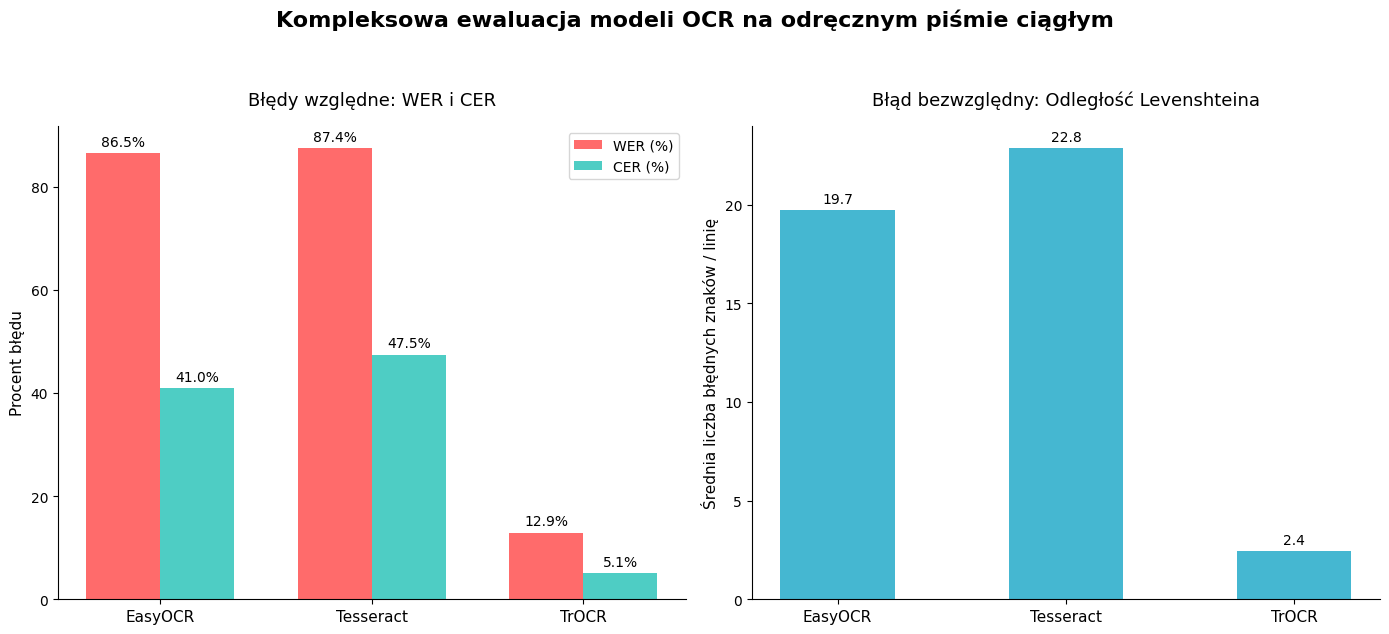

In [28]:
import matplotlib.pyplot as plt
import numpy as np

num_models = len(final_metrics)

wer_scores = [] 
cer_scores = [] 
lev_scores = [] 

models = ['EasyOCR', 'Tesseract', 'TrOCR']
for m in final_metrics:
    idx = models.index(m)
    print(idx)
    wer_scores.insert(idx, round(final_metrics[m]['wer']*100, 2))
    cer_scores.insert(idx, round(final_metrics[m]['cer']*100, 2))
    lev_scores.insert(idx, final_metrics[m]['levenshtein_dist'])
     
print(wer_scores, cer_scores, lev_scores)
x = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

rects1 = ax1.bar(x - width/2, wer_scores, width, label='WER (%)', color='#ff6b6b')
rects2 = ax1.bar(x + width/2, cer_scores, width, label='CER (%)', color='#4ecdc4')

ax1.set_ylabel('Procent błędu', fontsize=11)
ax1.set_title('Błędy względne: WER i CER', fontsize=13, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.legend(fontsize=10)
ax1.bar_label(rects1, padding=3, fmt='%.1f%%', fontsize=10)
ax1.bar_label(rects2, padding=3, fmt='%.1f%%', fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

rects3 = ax2.bar(x, lev_scores, width=0.5, label='Odległość Levenshteina', color='#45b7d1')

ax2.set_ylabel('Średnia liczba błędnych znaków / linię', fontsize=11)
ax2.set_title('Błąd bezwzględny: Odległość Levenshteina', fontsize=13, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=11)
ax2.bar_label(rects3, padding=3, fmt='%.1f', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Kompleksowa ewaluacja modeli OCR na odręcznym piśmie ciągłym', fontsize=16, fontweight='bold', y=1.05)

fig.tight_layout()

plt.savefig('ocr_comparison_full.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Wnioski z Fazy 1: Analiza porównawcza i wybór modelu docelowego

Przeprowadzony eksperyment ewaluacyjny dostarczył jednoznacznych danych na temat skuteczności różnych architektur sieci neuronowych w zadaniu odczytu trudnego, zlewającego się pisma odręcznego (zbioru IAM). Wyniki pozwoliły na weryfikację założeń teoretycznych i wyłonienie optymalnego silnika do dalszych etapów projektu.

### 6.1. Ograniczenia klasycznych algorytmów i systemów ogólnego przeznaczenia
Analiza metryk udowodniła, że pismo odręczne stanowi jedno z najtrudniejszych wyzwań dla systemów OCR:

1. **Porażka podejścia heurystycznego (Tesseract OCR):** Zgodnie z przewidywaniami, system pełniący rolę punktu odniesienia (Baseline) uzyskał najsłabsze wyniki. Wynika to z faktu, że jego silnik opiera się w dużej mierze na segmentacji pojedynczych znaków. Zlewająca się kursywa ludzka uniemożliwia prawidłowe wycięcie liter, co prowadzi do lawinowego wzrostu wskaźnika CER i utraty kontekstu słów.
2. **Problem przesunięcia dziedzinowego (EasyOCR):** Pomimo zastosowania potężnej, głębokiej architektury CRNN (Convolutional Recurrent Neural Network), model EasyOCR wygenerował błędy na poziomie ponad 40% (CER). Eksperyment ten doskonale obrazuje zjawisko tzw. *Domain Shift* (przesunięcia domenowego). Model ogólnego przeznaczenia, trenowany na wyraźnych czcionkach maszynowych i tekstach scenicznych, jest zjawiskowo nieskuteczny w zderzeniu z całkowicie inną dystrybucją danych (pismem ręcznym), uciekając się do "halucynowania" znaków, co widać po drastycznie wysokim błędzie odległości Levenshteina.

### 6.2. Triumf architektur Vision-Language (TrOCR)
Zdecydowanym zwycięzcą eksperymentu okazał się model **Microsoft TrOCR** w wariancie `base-handwritten`, deklasując konkurencję z wynikiem CER na poziomie zaledwie około 5%. 

Jego sukces wynika z dwóch kluczowych decyzji architektonicznych podjętych przez twórców:
* **Brak klasycznej segmentacji:** Zamiast analizować obraz piksel po pikselu, wizyjny koder (ViT) dzieli obraz na siatkę niezależnych fragmentów (patches), analizując ich globalny kontekst za pomocą mechanizmu *Self-Attention*.
* **Autoregresyjne modelowanie języka:** Dekoder oparty na architekturze RoBERTa nie zgaduje samych "kształtów" liter, ale przewiduje kolejne tokeny na podstawie silnego modelu językowego. Dzięki temu, nawet jeśli fizyczny kształt litery na obrazku przypomina bezkształtną plamę, TrOCR jest w stanie wywnioskować poprawną literę z kontekstu całego słowa i zdania (podobnie jak robi to ludzki mózg).
* **Specjalizacja dziedzinowa:** Model został poddany procesowi douczania (Fine-Tuning) wyłącznie na docelowej domenie pisma ręcznego.

### 6.3. Decyzja architektoniczna
Na podstawie zebranych metryk empirycznych (najniższe wartości WER, CER oraz odległości Levenshteina), **Microsoft TrOCR** zostaje wybrany jako główny moduł rozpoznawania tekstu (Text Recognition Engine) dla docelowej aplikacji powstającej w ramach projektu.